In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#POINTS = np.array([(10, 10), (20, 10)]) # Tuple of (bins, pulls) points
POINTS = np.array([(50, 10), (75, 10), (100, 10), (125, 10), (150, 10), (175, 10), (200, 10), (225, 10), (250, 10), (275, 10), 
                   (300, 10), (325, 10), (350, 10), (375, 10), (400, 10), (425, 10), (450, 10), (475, 10), (500, 10)])

In [3]:
process_times = np.array([])
fill_spectra_all_times = np.array([])
fill_spectra_phys_times = np.array([])
fill_spectra_nuis_times = np.array([])
chi2_times = np.array([])
chi2_with_grad_times = np.array([])

for bins, pulls in POINTS:
    with open(f'./scaling_outputs/scale_{bins}bins_{pulls}pulls.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_all_times = np.append(fill_spectra_all_times, time)
            elif 'fillspectra_vary_phys' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_phys_times = np.append(fill_spectra_phys_times, time)
            elif 'fillspectra_vary_nuis' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                fill_spectra_nuis_times = np.append(fill_spectra_nuis_times, time)
            elif 'metric_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                chi2_times = np.append(chi2_times, time)
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                chi2_with_grad_times = np.append(chi2_with_grad_times, time)
    f.close()

    with open(f'./time_logs/user_{bins}bins_{pulls}pulls_time.txt', 'r') as f2:
        line = f2.readline()
        time = float(line.split()[1].split('m')[0]) * 60 + float(line.split()[1].split('m')[1].split('s')[0])
        process_times = np.append(process_times, time)
    f2.close()

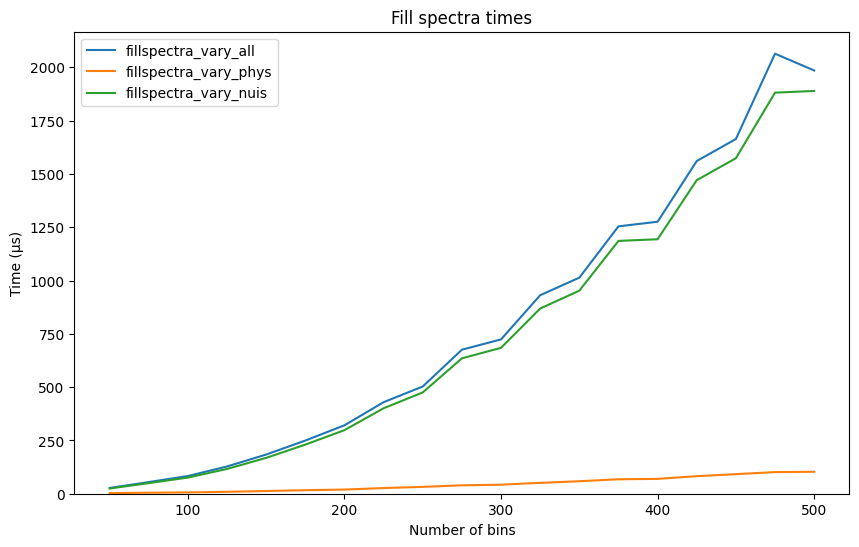

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS[:, 0], fill_spectra_all_times, label='fillspectra_vary_all')
plt.plot(POINTS[:, 0], fill_spectra_phys_times, label='fillspectra_vary_phys')
plt.plot(POINTS[:, 0], fill_spectra_nuis_times, label='fillspectra_vary_nuis')
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times')
plt.ylim(0,)
plt.show()

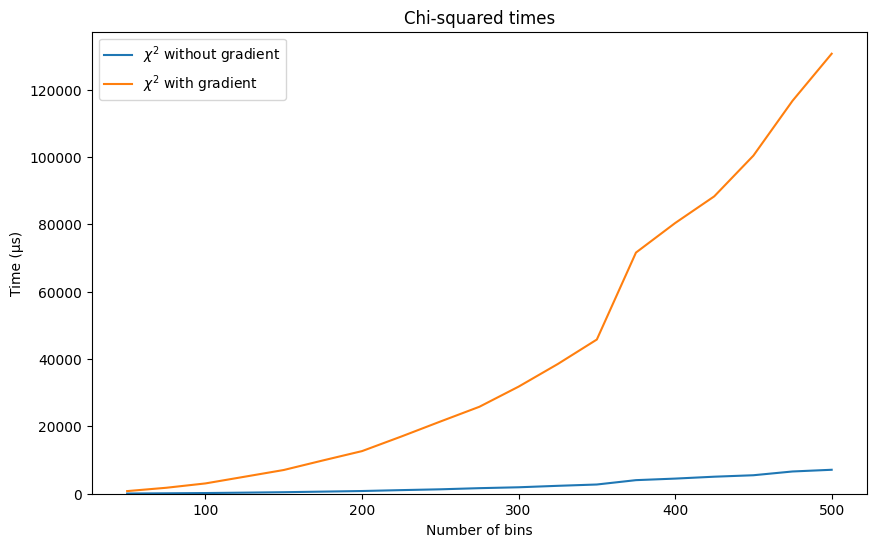

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS[:, 0], chi2_times, label='$\\chi^2$ without gradient')
plt.plot(POINTS[:, 0], chi2_with_grad_times, label='$\\chi^2$ with gradient')
plt.legend()
plt.xlabel('Number of bins')
plt.ylabel('Time (μs)')
plt.title('Chi-squared times')
plt.ylim(0,)
plt.show()

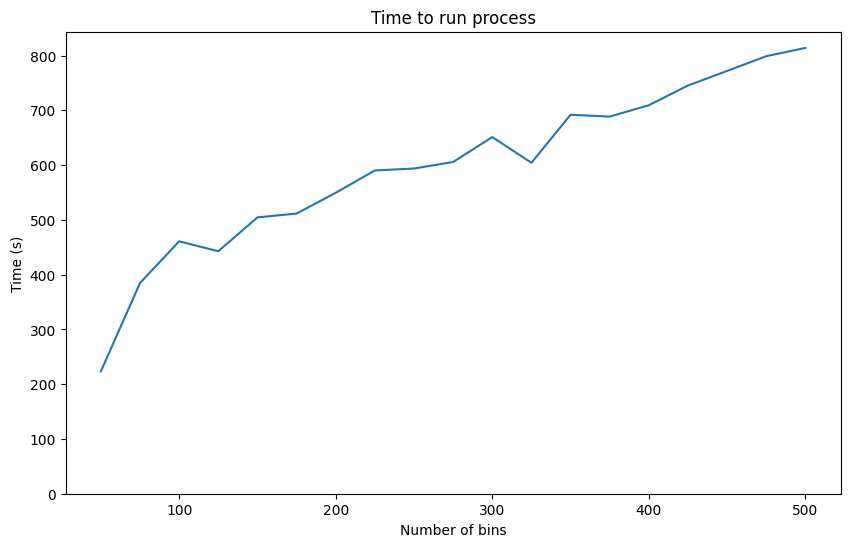

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(POINTS[:, 0], process_times)
plt.xlabel('Number of bins')
plt.ylabel('Time (s)')
plt.title('Time to run process')
plt.ylim(0,)
plt.show()